# Track 5: Group Relative Policy Optimization (GRPO) for Mathematical Reasoning

This notebook demonstrates fine-tuning on mathematical reasoning problems from the `openai/gsm8k` dataset using **Group Relative Policy Optimization (GRPO)** over 250 steps. We configure reinforcement learning rewards based on format correctness (1.0 weight) and solution accuracy (3.0 weight) to teach the model strict XML reasoning and answer tags (`<reasoning>` and `<answer>`).

## 1. Setup Environment and Imports
We load libraries and establish system prompt instructions enforcing a strict XML reasoning and answer format.

In [1]:
import re
import os
import sys
import glob
import torch
import warnings
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel, LoraConfig
from trl import GRPOTrainer, GRPOConfig

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

compute_dtype = (
    torch.bfloat16
    if torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
    else torch.float16
)

print(f"CUDA available: {torch.cuda.is_available()} | Compute Dtype: {compute_dtype}")

CUDA available: True | Compute Dtype: torch.bfloat16


## 2. Dataset Preparation (GSM8K)
We load the GSM8K dataset. We format each question with a system instruction that instructs the model to put its reasoning inside `<reasoning>` tags and the final numeric answer inside `<answer>` tags.

In [2]:
SYSTEM_PROMPT = (
    "A conversation between User and Assistant. The user asks a question, and the Assistant solves it.\n"
    "The assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\n"
    "The reasoning process and answer are enclosed within tags. The answer must be a single integer.\n"
    "Example:\n"
    "<reasoning>\n"
    "We know that 2 + 2 = 4.\n"
    "</reasoning>\n"
    "<answer>4</answer>"
)

def extract_hash_answer(text: str) -> str | None:
    if "####" not in text:
        return None
    return text.split("####")[1].strip()

dataset = load_dataset("openai/gsm8k", "main", split="train")
dataset = dataset.shuffle(seed=42)

def format_gsm8k(example):
    return {
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": example["question"]},
        ],
        "answer": extract_hash_answer(example["answer"]),
    }


gsm8k_train = dataset.map(format_gsm8k)

print("Sample Prompt Structure Preview:\n", gsm8k_train[0]["prompt"])

Sample Prompt Structure Preview:
 [{'role': 'system', 'content': 'A conversation between User and Assistant. The user asks a question, and the Assistant solves it.\nThe assistant first thinks about the reasoning process in the mind and then provides the user with the answer.\nThe reasoning process and answer are enclosed within tags. The answer must be a single integer.\nExample:\n<reasoning>\nWe know that 2 + 2 = 4.\n</reasoning>\n<answer>4</answer>'}, {'role': 'user', 'content': 'Mimi picked up 2 dozen seashells on the beach.  Kyle found twice as many shells as Mimi and put them in his pocket. Leigh grabbed one-third of the shells that Kyle found.  How many seashells did Leigh have?'}]


## 3. Define RL Rewards
We define two reward functions:
1. **Format Reward**: Returns `1.0` if the output strictly matches the `<reasoning>...</reasoning>\n<answer>...</answer>` tags.
2. **Correctness Reward**: Returns `2.0` if the extracted answer matches the ground truth, and `0.0` otherwise.

In [3]:
def extract_last_number(text, start_tag="<answer>", end_tag="</answer>"):
    pattern = re.escape(start_tag) + r"(.*?)" + re.escape(end_tag)
    matches = re.findall(pattern, text, re.DOTALL)
    text_to_search = matches[-1] if matches else text
    numbers = re.findall(r"-?\d+(?:,\d{3})*(?:\.\d+)?", text_to_search)
    if numbers:
        return numbers[-1].replace(",", "").strip()
    return ""

def extract_answer(text):
    return extract_last_number(text)

# 1. Graduated Format Reward (Max: 0.5)
def format_reward(completions, **kwargs):
    responses = [completion[0]["content"] for completion in completions]
    rewards = []
    for response in responses:
        score = 0.0
        if "<reasoning>" in response: score += 0.1
        if "</reasoning>" in response: score += 0.1
        if "<answer>" in response: score += 0.1
        if "</answer>" in response: score += 0.1
        
        pattern = r"^<reasoning>[\s\S]*?<\/reasoning>\s*<answer>[\s\S]*?<\/answer>$"
        if re.match(pattern, response):
            score += 0.1
            
        rewards.append(score)
    return rewards

# 2. Math Step / Equation Reward (Replaces raw length reward, Max: 0.5)
def math_step_reward(completions, **kwargs):
    """
    Rewards generating actual mathematical calculations (e.g., '16 - 7 = 9')
    rather than just filling space with words.
    """
    responses = [completion[0]["content"] for completion in completions]
    rewards = []
    for response in responses:
        match = re.search(r"<reasoning>(.*?)</reasoning>", response, re.DOTALL)
        if match:
            text = match.group(1)
            # Find explicit arithmetic operations like "16 - 7 = 9" or "180 / 3 = 60"
            equations = re.findall(r"\d+\s*[\+\-\*/]\s*\d+\s*=\s*\d+", text)
            eq_count = len(equations)
            
            # Award +0.15 per equation, capped at 0.5 max
            rewards.append(min(0.5, eq_count * 0.15))
        else:
            rewards.append(0.0)
    return rewards

# 3. Partial Correctness Reward (Max: 0.5)
def partial_correctness_reward(completions, answer, **kwargs):
    responses = [completion[0]["content"] for completion in completions]
    rewards = []
    for response, ans in zip(responses, answer):
        if ans and re.search(r"\b" + re.escape(str(ans)) + r"\b", response):
            rewards.append(0.5)
        else:
            rewards.append(0.0)
    return rewards

# 4. Strict Final Correctness Reward (Max: 2.0)
def correctness_reward(completions, answer, **kwargs):
    responses = [completion[0]["content"] for completion in completions]
    extracted = [extract_last_number(response) for response in responses]
    rewards = [2.0 if ext == ans else 0.0 for ext, ans in zip(extracted, answer)]
    return rewards

## 3.5. Evaluate Pre-Trained Model Before GRPO Alignment
To demonstrate GRPO's capability to teach both format compliance and mathematical accuracy, we evaluate the un-finetuned model on 5 test questions from GSM8K before starting RL training.

In [4]:
HF_REPO_ID = "Qwen/Qwen2.5-0.5B-Instruct"
MODEL_NAME = HF_REPO_ID.split("/")[-1].lower()

In [5]:
tokenizer = AutoTokenizer.from_pretrained(HF_REPO_ID)

base_model_eval = AutoModelForCausalLM.from_pretrained(
    HF_REPO_ID, dtype=compute_dtype, device_map="auto"
)
base_model_eval.eval()
base_model_eval.generation_config.max_length = None

eval_dataset_100 = load_dataset("openai/gsm8k", "main", split="test").select(range(100))
pre_grpo_responses_100 = []
pre_grpo_correct = 0
pre_grpo_format = 0

pattern = r"^<reasoning>[\s\S]*?<\/reasoning>\s*<answer>[\s\S]*?<\/answer>$"


print("=== Running Pre-GRPO Benchmark on 100 GSM8K Test Problems ===")

for i, example in enumerate(eval_dataset_100):
    question = example["question"]
    ground_truth = extract_hash_answer(example["answer"])
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )
    input_ids = inputs if isinstance(inputs, torch.Tensor) else inputs["input_ids"]
    input_ids = input_ids.to("cuda")

    with torch.no_grad():
        outputs = base_model_eval.generate(
            input_ids=input_ids, max_new_tokens=2048, pad_token_id=tokenizer.eos_token_id
        )

    resp = tokenizer.decode(
        outputs[0][input_ids.shape[1] :], skip_special_tokens=True
    ).strip()

    pre_grpo_responses_100.append(resp)
    ext_ans = extract_last_number(resp)

    if ext_ans == ground_truth:
        pre_grpo_correct += 1

    if re.match(pattern, resp):
        pre_grpo_format += 1

    if (i + 1) % 20 == 0:
        print(
            f"Evaluated {i + 1}/100 problems | Current Accuracy: {pre_grpo_correct / (i + 1) * 100:.1f}%"
        )

pre_acc = (pre_grpo_correct / 100) * 100
pre_fmt = (pre_grpo_format / 100) * 100

print(f"\n>>> PRE-GRPO BENCHMARK (100 Problems) <<<")
print(f"Format Compliance: {pre_fmt:.1f}% ({pre_grpo_format}/100)")
print(f"Math Accuracy:     {pre_acc:.1f}% ({pre_grpo_correct}/100)\n")


# Free GPU VRAM
del base_model_eval
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

=== Running Pre-GRPO Benchmark on 100 GSM8K Test Problems ===


Evaluated 20/100 problems | Current Accuracy: 40.0%


Evaluated 40/100 problems | Current Accuracy: 32.5%


Evaluated 60/100 problems | Current Accuracy: 31.7%


Evaluated 80/100 problems | Current Accuracy: 28.7%


Evaluated 100/100 problems | Current Accuracy: 31.0%

>>> PRE-GRPO BENCHMARK (100 Problems) <<<
Format Compliance: 0.0% (0/100)
Math Accuracy:     31.0% (31/100)



## 4. Run GRPOTrainer using vLLM
We load the tokenizer and define the LoRA parameters. We use `vLLM` inside the trainer with a configured device and VRAM footprint to scale policy rollouts rapidly.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(HF_REPO_ID)

peft_config = LoraConfig(
    lora_alpha=64,
    lora_dropout=0.0,
    r=64,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

training_args = GRPOConfig(
    use_vllm=True,
    learning_rate=1e-5,
    adam_beta1=0.9,
    adam_beta2=0.99,
    weight_decay=0.1,
    warmup_steps=25,
    beta=0.02,
    lr_scheduler_type="cosine",
    optim="adamw_8bit",
    bf16=(compute_dtype == torch.bfloat16),
    fp16=(compute_dtype == torch.float16),
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    gradient_accumulation_steps=8,
    per_device_train_batch_size=2,
    num_generations=16,
    temperature=1.0,
    max_completion_length=2048,
    max_steps=850,
    logging_steps=50,
    save_steps=50,
    max_grad_norm=1.0,
    report_to="none",
    output_dir= MODEL_NAME + "-grpo-output",
)

model = AutoModelForCausalLM.from_pretrained(
    HF_REPO_ID, dtype=compute_dtype, device_map="auto"
)

if not hasattr(model, "warnings_issued"):
    model.warnings_issued = {}


trainer = GRPOTrainer(
    model=model,
    processing_class=tokenizer,
    reward_funcs=[
        format_reward,
        math_step_reward,
        partial_correctness_reward,
        correctness_reward, 
        ],
    args=training_args,
    train_dataset=gsm8k_train,
    peft_config=peft_config,
)

trainer.train()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


2026-07-23 14:45:12,964 - INFO - autotuner.py:651 - flashinfer.jit: [Autotuner]: Autotuning process starts ...


2026-07-23 14:45:13,018 - INFO - autotuner.py:674 - flashinfer.jit: [Autotuner]: Autotuning process ends


Capturing CUDA graphs (PIECEWISE):   0%|          | 0/7 [00:00<?, ?it/s]

...

Capturing CUDA graphs (FULL):  40%|████      | 2/5 [00:00<00:00, 19.81it/s]

Capturing CUDA graphs (FULL): 100%|██████████| 5/5 [00:00<00:00, 38.15it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
50,0.028577
100,-0.058427
150,-0.108338
200,-0.059779
250,-0.078151
300,-0.056680
350,-0.009999
400,-0.092800
450,-0.063045
500,0.040020


TrainOutput(global_step=850, training_loss=-0.04909141407293432, metrics={'train_runtime': 4048.075, 'train_samples_per_second': 3.36, 'train_steps_per_second': 0.21, 'total_flos': 0.0, 'train_loss': -0.04909141407293432, 'epoch': 0.11374280744011776})

In [7]:
merged_model = trainer.model.merge_and_unload()
tokenizer.save_pretrained(MODEL_NAME + "-grpo-adapter")
merged_model.save_pretrained(MODEL_NAME + "-grpo-adapter")
print("GRPO training completed and model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GRPO training completed and model saved!


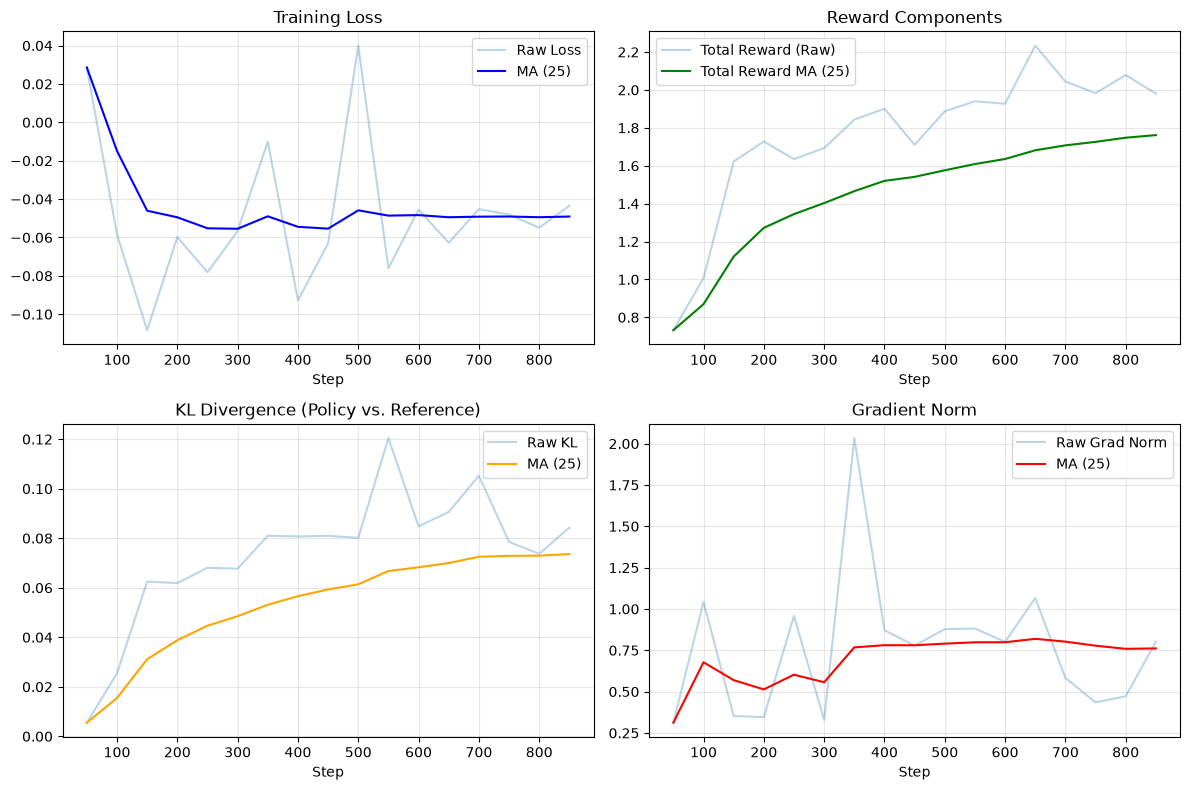

In [8]:
# Extract logs and drop any non-step entries
logs = pd.DataFrame(trainer.state.log_history)
logs = logs[logs["step"].notna()]  

n = 25  # Moving average window parameter

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Training Loss
if "loss" in logs:
    logs["loss_ma"] = logs["loss"].rolling(window=n, min_periods=1).mean()
    axes[0, 0].plot(logs["step"], logs["loss"], alpha=0.3, label="Raw Loss")
    axes[0, 0].plot(logs["step"], logs["loss_ma"], color="blue", label=f"MA ({n})")
    axes[0, 0].set_title("Training Loss")
    axes[0, 0].legend()

# 2. Reward Components
if "reward" in logs:
    logs["reward_ma"] = logs["reward"].rolling(window=n, min_periods=1).mean()
    axes[0, 1].plot(logs["step"], logs["reward"], alpha=0.3, label="Total Reward (Raw)")
    axes[0, 1].plot(logs["step"], logs["reward_ma"], color="green", label=f"Total Reward MA ({n})")
    
    if "rewards/correctness_reward" in logs:
        logs["correctness_ma"] = logs["rewards/correctness_reward"].rolling(window=n, min_periods=1).mean()
        axes[0, 1].plot(logs["step"], logs["correctness_ma"], label=f"Correctness MA", alpha=0.8)
        
    if "rewards/format_reward" in logs:
        logs["format_ma"] = logs["rewards/format_reward"].rolling(window=n, min_periods=1).mean()
        axes[0, 1].plot(logs["step"], logs["format_ma"], label=f"Format MA", alpha=0.8)
        
    axes[0, 1].set_title("Reward Components")
    axes[0, 1].legend()

# 3. KL Divergence
if "kl" in logs:
    logs["kl_ma"] = logs["kl"].rolling(window=n, min_periods=1).mean()
    axes[1, 0].plot(logs["step"], logs["kl"], alpha=0.3, label="Raw KL")
    axes[1, 0].plot(logs["step"], logs["kl_ma"], color="orange", label=f"MA ({n})")
    axes[1, 0].set_title("KL Divergence (Policy vs. Reference)")
    axes[1, 0].legend()

# 4. Gradient Norm
if "grad_norm" in logs:
    logs["grad_norm_ma"] = logs["grad_norm"].rolling(window=n, min_periods=1).mean()
    axes[1, 1].plot(logs["step"], logs["grad_norm"], alpha=0.3, label="Raw Grad Norm")
    axes[1, 1].plot(logs["step"], logs["grad_norm_ma"], color="red", label=f"MA ({n})")
    axes[1, 1].set_title("Gradient Norm")
    axes[1, 1].legend()

for ax in axes.flat:
    ax.set_xlabel("Step")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_ma.png", dpi=150)
plt.show()

## 5. Inference Verification
We query our trained model to verify that it generates reasoning and mathematical solutions structured under correct tags.

In [9]:
merged_model.eval()
merged_model.generation_config.max_length = None

post_grpo_responses_100 = []
post_grpo_correct = 0
post_grpo_format = 0

print("=== Running Post-GRPO Benchmark on 100 GSM8K Test Problems ===")

for i, example in enumerate(eval_dataset_100):
    question = example["question"]
    ground_truth = extract_hash_answer(example["answer"])

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )

    input_ids = inputs if isinstance(inputs, torch.Tensor) else inputs["input_ids"]
    input_ids = input_ids.to("cuda")

    with torch.no_grad():
        outputs = merged_model.generate(
            input_ids=input_ids, max_new_tokens=2048, pad_token_id=tokenizer.eos_token_id
        )

    post_resp = tokenizer.decode(
        outputs[0][input_ids.shape[1] :], skip_special_tokens=True
    ).strip()

    post_grpo_responses_100.append(post_resp)
    ext_ans = extract_last_number(post_resp)

    if ext_ans == ground_truth:
        post_grpo_correct += 1

    if re.match(pattern, post_resp):
        post_grpo_format += 1

    if (i + 1) % 20 == 0:
        print(
            f"Evaluated {i + 1}/100 problems | Current Accuracy: {post_grpo_correct / (i + 1) * 100:.1f}%"
        )

post_acc = (post_grpo_correct / 100) * 100
post_fmt = (post_grpo_format / 100) * 100
acc_delta = post_acc - pre_acc
fmt_delta = post_fmt - pre_fmt

print("\n" + "=" * 60)
print(">>> FINAL GSM8K 100-PROBLEM BENCHMARK RESULTS <<<")
print(f"Pre-GRPO Format Compliance:  {pre_fmt:.1f}%")
print(f"Post-GRPO Format Compliance: {post_fmt:.1f}%")
print(f"Format Compliance Delta:    {'+' if fmt_delta >= 0 else ''}{fmt_delta:.1f}%\n")
print(f"Pre-GRPO Math Accuracy:      {pre_acc:.1f}%")
print(f"Post-GRPO Math Accuracy:     {post_acc:.1f}%")
print(f"Math Accuracy Delta:        {'+' if acc_delta >= 0 else ''}{acc_delta:.1f}%")
print("=" * 60 + "\n")
print("=== Detailed 5-Example Side-by-Side Comparison ===")

for i in range(5):
    example = eval_dataset_100[i]
    question = example["question"]
    ground_truth = extract_hash_answer(example["answer"])
    print(f"=== Test Example {i + 1} ===")
    print(f"Question: {question}")
    print(f"Ground Truth Answer: {ground_truth}")
    print(
        f"\033[91mBefore GRPO (Pre-trained Model):\033[0m\n{pre_grpo_responses_100[i]}\n"
    )
    print(
        f"\033[92mAfter GRPO (RL Aligned Model):\033[0m\n{post_grpo_responses_100[i]}\n"
    )
    print("-" * 80 + "\n")

=== Running Post-GRPO Benchmark on 100 GSM8K Test Problems ===


Evaluated 20/100 problems | Current Accuracy: 45.0%


Evaluated 40/100 problems | Current Accuracy: 50.0%


Evaluated 60/100 problems | Current Accuracy: 53.3%


Evaluated 80/100 problems | Current Accuracy: 51.2%


Evaluated 100/100 problems | Current Accuracy: 51.0%

>>> FINAL GSM8K 100-PROBLEM BENCHMARK RESULTS <<<
Pre-GRPO Format Compliance:  0.0%
Post-GRPO Format Compliance: 92.0%
Format Compliance Delta:    +92.0%

Pre-GRPO Math Accuracy:      31.0%
Post-GRPO Math Accuracy:     51.0%
Math Accuracy Delta:        +20.0%

=== Detailed 5-Example Side-by-Side Comparison ===
=== Test Example 1 ===
Question: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?
Ground Truth Answer: 18
Before GRPO (Pre-trained Model):
First, we calculate how many eggs Janet's ducks lay each day: 16.

Next, we determine how many eggs she eats in a day: 3 (breakfast) + 4 (baking) = 7 eggs.

Then, we find out how many eggs she has left to sell by subtracting the number of eggs she eats from the t